# 11 — Case 2 v3: Forecasting on Top of the Frozen Contrastive Representation

Adds the "forecasting lego-block" from
[docs/case2-3-design-plan.md §2.4](../docs/case2-3-design-plan.md#24-generation-v2stretch--where-predict-the-next-timepoint-reappears):
a ridge-regression linear probe on the *frozen* Case 2 brain encoder's
pooled features, predicting future ROI activity at increasing horizons —
how far ahead does the representation actually carry usable signal?

**Leak-safety**: windows are built with
`data_setup.build_forecast_window_index()`, which only keeps a
window if the forecast target's condition label matches the window's own
current label — a large horizon can never silently cross into an
*adjacent* MOTOR condition block. At horizon=32 this correctly returns
zero windows, since MOTOR blocks (~12s / ~16-17 TRs) aren't long enough
to survive that horizon without crossing a boundary.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders, make_forecast_dataloaders
from neurolens.model_builder import TransformerDecoder
from neurolens.retrieval import load_embedding_model
from neurolens.contrastive import (
    ContrastiveModel,
    TextPrototypeEncoder,
    encode_condition_prototypes,
    get_device,
    train_forecast_head,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "case2_transformer_w32" / "best.pt"
EMBED_DIM = 64

device = get_device()
_, _, _, info = make_dataloaders(PROCESSED_ROOT, batch_size=64, window_length=32)

embedding_model = load_embedding_model()
text_embeddings = encode_condition_prototypes(embedding_model, info["class_to_condition"])

backbone = TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)
text_encoder = TextPrototypeEncoder(text_embeddings, embed_dim=EMBED_DIM)
model = ContrastiveModel(backbone, backbone_dim=128, text_encoder=text_encoder, embed_dim=EMBED_DIM)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()
print("loaded frozen Case 2 backbone from", CHECKPOINT_PATH)


/Users/srinivasgovindasurampudi/miniconda3/envs/neurolens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6848.44it/s]

loaded frozen Case 2 backbone from /Users/srinivasgovindasurampudi/Projects/neurolens-rag/models/case2_transformer_w32/best.pt


## 1. Horizon sweep

In [2]:
HORIZONS = [1, 2, 3, 4, 6, 8, 12, 16, 20, 24]  # in TRs (TR = 0.72s)
TR_SECONDS = 0.72

horizon_results = []
for h in HORIZONS:
    train_loader, val_loader, test_loader, finfo = make_forecast_dataloaders(PROCESSED_ROOT, horizon=h)
    if finfo["n_train_windows"] == 0 or finfo["n_test_windows"] == 0:
        print(f"horizon={h} ({h*TR_SECONDS:.1f}s): no leak-free windows survive - skipping")
        continue
    result = train_forecast_head(model, train_loader, val_loader, test_loader, device)
    horizon_results.append({
        "horizon_trs": h,
        "horizon_seconds": round(h * TR_SECONDS, 2),
        "n_train": result["n_train"],
        "n_test": result["n_test"],
        "test_mse": result["test_mse"],
        "test_mae": result["test_mae"],
        "test_r2": result["test_r2"],
    })
    print(f"horizon={h} ({h*TR_SECONDS:.1f}s): n_train={result['n_train']} n_test={result['n_test']} "
          f"test_r2={result['test_r2']:.4f} test_mse={result['test_mse']:.4f}")

horizon_df = pd.DataFrame(horizon_results)
horizon_df


horizon=1 (0.7s): n_train=3332 n_test=714 test_r2=0.2962 test_mse=0.6858


horizon=2 (1.4s): n_train=3192 n_test=684 test_r2=0.1933 test_mse=0.7810


horizon=3 (2.2s): n_train=2968 n_test=636 test_r2=0.1066 test_mse=0.8728


horizon=4 (2.9s): n_train=2828 n_test=606 test_r2=0.0349 test_mse=0.9308


horizon=6 (4.3s): n_train=2464 n_test=528 test_r2=-0.0515 test_mse=1.0048


horizon=8 (5.8s): n_train=2100 n_test=450 test_r2=-0.0879 test_mse=1.0322
horizon=12 (8.6s): n_train=1400 n_test=300 test_r2=-0.1192 test_mse=1.0382


horizon=16 (11.5s): n_train=784 n_test=168 test_r2=-0.1663 test_mse=1.0682
horizon=20 (14.4s): n_train=196 n_test=42 test_r2=-1.1309 test_mse=1.7759
horizon=24 (17.3s): no leak-free windows survive - skipping


,horizon_trs,horizon_seconds,n_train,n_test,test_mse,test_mae,test_r2
0,1,0.72,3332,714,0.685850,0.652922,0.296228
1,2,1.44,3192,684,0.781040,0.699047,0.193266
2,3,2.16,2968,636,0.872796,0.740784,0.106552
3,4,2.88,2828,606,0.930788,0.764923,0.034917
4,6,4.32,2464,528,1.004779,0.795755,-0.051532
5,8,5.76,2100,450,1.032238,0.804172,-0.087861
6,12,8.64,1400,300,1.038249,0.807272,-0.119207
7,16,11.52,784,168,1.068209,0.819604,-0.166299
8,20,14.40,196,42,1.775937,1.053951,-1.130922


## 2. Visualize: forecast quality and sample count vs. horizon

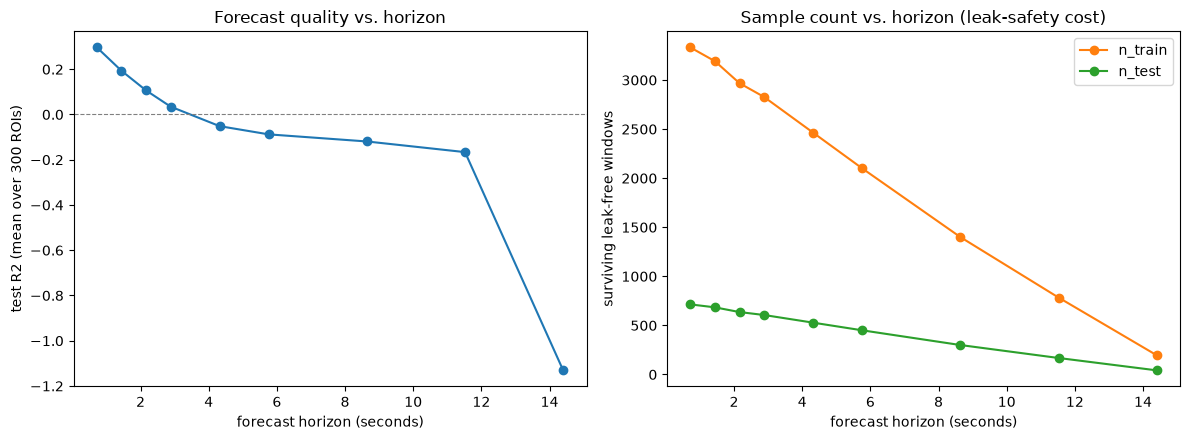

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(horizon_df["horizon_seconds"], horizon_df["test_r2"], marker="o", color="C0")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("forecast horizon (seconds)")
axes[0].set_ylabel("test R2 (mean over 300 ROIs)")
axes[0].set_title("Forecast quality vs. horizon")

axes[1].plot(horizon_df["horizon_seconds"], horizon_df["n_train"], marker="o", color="C1", label="n_train")
axes[1].plot(horizon_df["horizon_seconds"], horizon_df["n_test"], marker="o", color="C2", label="n_test")
axes[1].set_xlabel("forecast horizon (seconds)")
axes[1].set_ylabel("surviving leak-free windows")
axes[1].set_title("Sample count vs. horizon (leak-safety cost)")
axes[1].legend()

fig.tight_layout()
plt.show()


## 3. Reading the result

Forecast quality (R²) decays quickly and is **confounded with sample size** — both fall together as horizon grows, since only windows deep enough inside a condition block survive the leak-safety filter at large horizons. This sweep alone can't fully separate "genuinely harder to predict further ahead" from "fewer training examples at large horizons," but the R² crossing zero by horizon 6-8 (still thousands of training samples, not yet a tiny-sample regime) suggests the dominant effect is real signal decay, not sample scarcity — the frozen representation's forward-predictive content runs out well before the sample count becomes the limiting factor. Worth deconfounding properly later (e.g., subsample the horizon=1 training set down to the horizon=16 count and check whether R² holds up) before treating this as a clean scientific claim rather than a first-pass engineering read.


## 4. Save results

In [4]:
summary = {"horizon_sweep": horizon_df.to_dict(orient="records")}
results_path = RESULTS_DIR / "case2_forecasting_results.json"
import json
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)
print("saved:", results_path)


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/case2_forecasting_results.json


## Summary

**The frozen Case 2 representation carries real forward-predictive signal for roughly 3-4 seconds (4-6 TRs), then decays to noise**: test R2 = 0.296 at horizon=1 TR (0.7s), falling smoothly through 0.19 (h=2), 0.11 (h=3), 0.03 (h=4), crossing zero between horizon 4 and 6 TRs, then staying mildly negative (worse than predicting the mean) from h=6 through h=16 (-0.05 to -0.17).

**One point to discount, not report as a continuation of the trend**: horizon=20 (14.4s) shows a much sharper drop (R2=-1.13), but only 196 training windows survive the leak-safety filter at that horizon — an order of magnitude fewer than at horizon=1 (3,332). That's almost certainly undertrained-probe noise, not a real acceleration of signal decay; the sample-count confound flagged in §3 is dominant there. Horizon=24 (17.3s) correctly returns **zero** leak-free windows, confirming the leak-safety filter is working exactly as intended at the boundary — MOTOR condition blocks are only ~12s (~16-17 TRs) long, so no window can survive a 24-TR horizon without crossing into an adjacent condition.

**Answering the original question** ("how much horizon can we predict"): with this representation and this linear probe, about 3-4 seconds — short relative to a 12-second condition block, meaning far-horizon forecasting isn't free lunch from the current Case 2 representation. Two follow-ups worth doing before drawing a firm conclusion: (1) properly deconfound sample size from horizon (subsample horizon=1's training set down to smaller horizons' counts and see if R2 holds up), and (2) test whether a *non-frozen*, forecasting-fine-tuned backbone (or a Case 3 dynamical-systems model, which is built for exactly this) extends the usable horizon meaningfully further.

Full numbers: [results/case2_forecasting_results.json](../results/case2_forecasting_results.json). Findings folded into [docs/case2-3-design-plan.md](../docs/case2-3-design-plan.md).
